# Load scanpy, anndata, and matplotlib.pyplot

In [47]:
import scanpy as sc
import anndata as ad
import celltypist
from celltypist import models

# Read in samples separately (Find an appropriate function to read in 10x data from a matrix)

In [48]:
sample1 = sc.read_10x_mtx('/projectnb/bf528/materials/single_cell/hipp_rep1/outs/filtered_feature_bc_matrix/')
sample2 = sc.read_10x_mtx('/projectnb/bf528/materials/single_cell/hipp_rep2/outs/filtered_feature_bc_matrix/')

# How many genes and cells are present in each sample? (Use the .var and .obs dataframes)

In [49]:
sample1.obs

""
AAACCTGAGATGCCAG-1
AAACCTGAGGCGCTCT-1
AAACCTGCAACACCTA-1
AAACCTGCATGCCTAA-1
AAACCTGGTCGAACAG-1
...
TTTGTCAGTTGCGCAC-1
TTTGTCATCAATCTCT-1
TTTGTCATCACTGGGC-1
TTTGTCATCGATCCCT-1


In [50]:
sample2

AnnData object with n_obs × n_vars = 9283 × 33696
    var: 'gene_ids', 'feature_types'

# Identify which genes correspond to mitochondrial, ribosomal and hemoglobin genes per barcode

In [51]:
sample1.var["mt"] = sample1.var_names.str.startswith("mt-")
sample1.var["ribo"] = sample1.var_names.str.startswith(("Rps", "Rpl"))
sample1.var["hb"] = sample1.var_names.str.contains("^Hb[^(P)]")

sample2.var["mt"] = sample2.var_names.str.startswith("mt-")
sample2.var["ribo"] = sample2.var_names.str.startswith(("Rps", "Rpl"))
sample2.var["hb"] = sample2.var_names.str.contains("^Hb[^(P)]")

In [52]:
sample1.var

,gene_ids,feature_types,mt,ribo,hb
Xkr4,ENSMUSG00000051951,Gene Expression,False,False,False
Gm1992,ENSMUSG00000089699,Gene Expression,False,False,False
Gm19938,ENSMUSG00000102331,Gene Expression,False,False,False
Gm37381,ENSMUSG00000102343,Gene Expression,False,False,False
Rp1,ENSMUSG00000025900,Gene Expression,False,False,False
...,...,...,...,...,...
ENSMUSG00000095523,ENSMUSG00000095523,Gene Expression,False,False,False
ENSMUSG00000095475,ENSMUSG00000095475,Gene Expression,False,False,False
ENSMUSG00000094855,ENSMUSG00000094855,Gene Expression,False,False,False
ENSMUSG00000095019,ENSMUSG00000095019,Gene Expression,False,False,False


# Actually calculate QC metrics per barcode / cell

In [53]:
sc.pp.calculate_qc_metrics(
    sample1, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

sc.pp.calculate_qc_metrics(
    sample2, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

# Access the .obs and return a dataframe only containing cells with less than 1000 genes

### This is just practice subsetting anndata objects with pandas-like operations

In [54]:
sample1.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
AAACCTGAGATGCCAG-1,2409,7.787382,4126.0,8.325306,19.946680,25.666505,33.858459,50.096946,346.0,5.849325,8.385846,255.0,5.545177,6.180320,0.0,0.000000,0.000000
AAACCTGAGGCGCTCT-1,2273,7.729296,5077.0,8.532673,23.616309,32.263148,43.116013,59.661217,320.0,5.771441,6.302935,660.0,6.493754,12.999803,1.0,0.693147,0.019697
AAACCTGCAACACCTA-1,1929,7.565275,3646.0,8.201660,25.150850,32.364235,41.689523,59.544707,214.0,5.370638,5.869446,293.0,5.683580,8.036204,2.0,1.098612,0.054855
AAACCTGCATGCCTAA-1,3830,8.250881,10013.0,9.211740,17.367422,25.137321,35.513832,51.612903,369.0,5.913503,3.685209,957.0,6.864848,9.557575,0.0,0.000000,0.000000
AAACCTGGTCGAACAG-1,1125,7.026427,1750.0,7.467942,26.457143,34.457143,45.885714,64.285714,118.0,4.779123,6.742857,105.0,4.663439,6.000000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTTGCGCAC-1,1790,7.490529,3283.0,8.096817,24.703016,33.170880,43.253122,60.706671,159.0,5.075174,4.843132,497.0,6.210600,15.138594,0.0,0.000000,0.000000
TTTGTCATCAATCTCT-1,348,5.855072,533.0,6.280396,43.527205,53.470919,72.232645,100.000000,110.0,4.709530,20.637897,35.0,3.583519,6.566604,0.0,0.000000,0.000000
TTTGTCATCACTGGGC-1,1074,6.980076,1983.0,7.592870,27.937468,38.275340,50.882501,71.053959,199.0,5.298317,10.035300,245.0,5.505332,12.355018,1.0,0.693147,0.050429
TTTGTCATCGATCCCT-1,2479,7.816014,5206.0,8.557759,20.303496,28.275067,38.820592,55.781790,283.0,5.648974,5.436035,507.0,6.230482,9.738763,0.0,0.000000,0.000000


# How many cells / barcodes have less than 1000 genes in each sample?

In [55]:
sample1.obs[sample1.obs['n_genes_by_counts'] < 1000]

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
AAACCTGGTGCGCTTG-1,489,6.194405,761.0,6.635947,37.319317,48.883049,62.023653,100.000000,82.0,4.418840,10.775295,42.0,3.761200,5.519054,0.0,0.000000,0.000000
AAACCTGGTTAAGACA-1,859,6.756932,1461.0,7.287560,29.500342,40.109514,53.935661,75.427789,111.0,4.718499,7.597536,186.0,5.231109,12.731007,0.0,0.000000,0.000000
AAACCTGTCTTGGGTA-1,459,6.131226,594.0,6.388561,30.303030,39.562290,56.397306,100.000000,35.0,3.583519,5.892256,20.0,3.044523,3.367003,0.0,0.000000,0.000000
AAACGGGAGCTGTCTA-1,719,6.579251,1092.0,6.996682,27.380952,37.820513,52.472527,79.945055,77.0,4.356709,7.051282,202.0,5.313206,18.498169,0.0,0.000000,0.000000
AAACGGGAGTATCTCG-1,876,6.776507,1439.0,7.272398,32.939541,40.861710,53.022933,73.870744,156.0,5.056246,10.840861,45.0,3.828641,3.127172,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCGCCAATTCCTT-1,964,6.872128,1564.0,7.355641,31.841432,39.514066,51.150895,70.332481,236.0,5.468060,15.089514,34.0,3.555348,2.173913,0.0,0.000000,0.000000
TTTGCGCGTATTCGTG-1,610,6.415097,940.0,6.846943,33.297872,43.936170,56.382979,88.297872,133.0,4.897840,14.148935,95.0,4.564348,10.106383,1.0,0.693147,0.106383
TTTGTCAAGGTGCAAC-1,391,5.971262,528.0,6.270988,32.007576,44.886364,63.825758,100.000000,45.0,3.828641,8.522727,102.0,4.634729,19.318182,0.0,0.000000,0.000000
TTTGTCAAGTGGTAAT-1,519,6.253829,768.0,6.645091,30.859375,43.880208,58.463542,97.526042,69.0,4.248495,8.984375,102.0,4.634729,13.281250,0.0,0.000000,0.000000


# Plot both sample's QC metrics with violin plots

... storing 'feature_types' as categorical


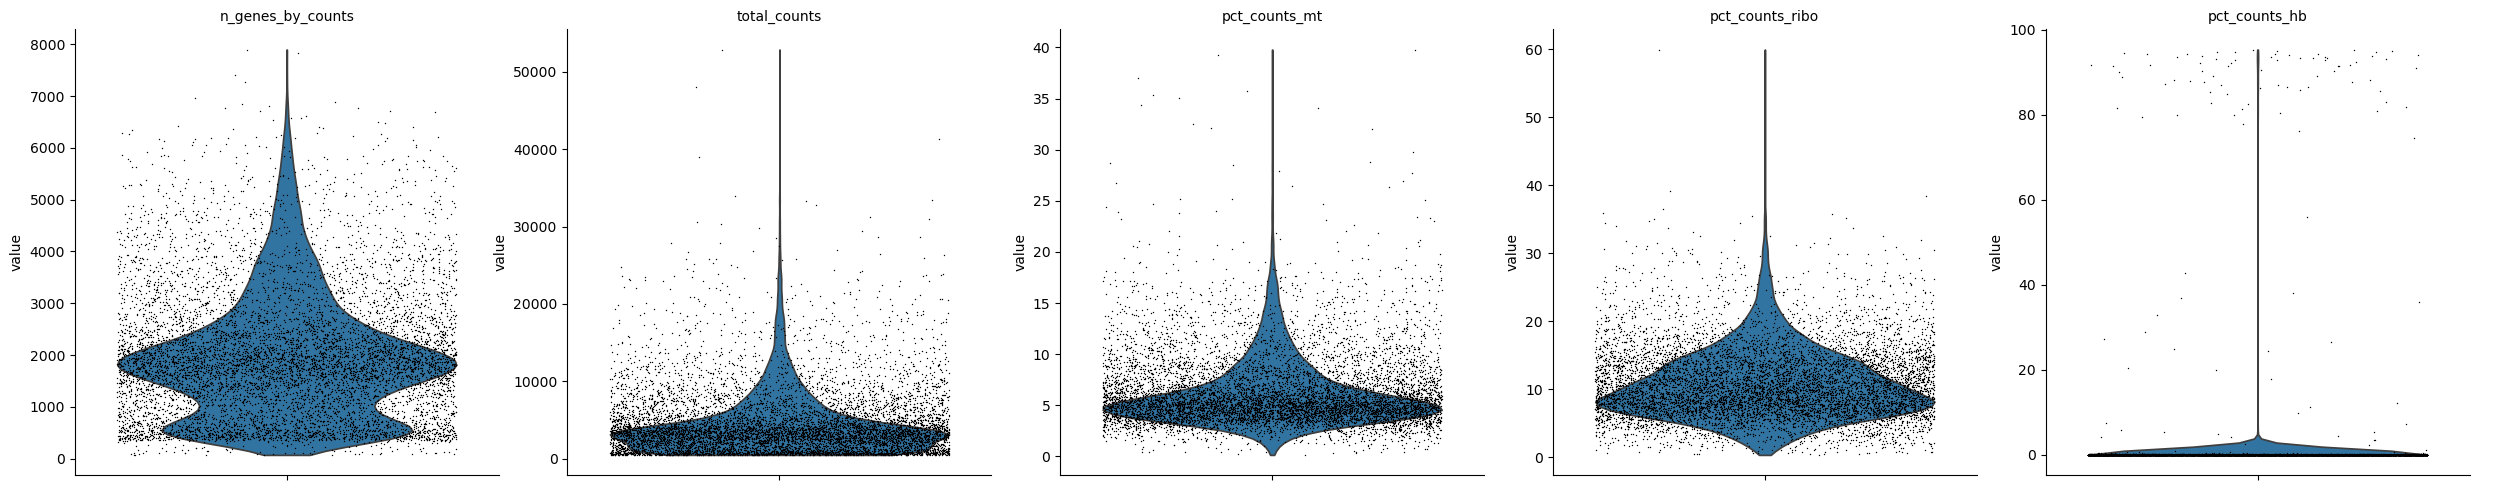

... storing 'feature_types' as categorical


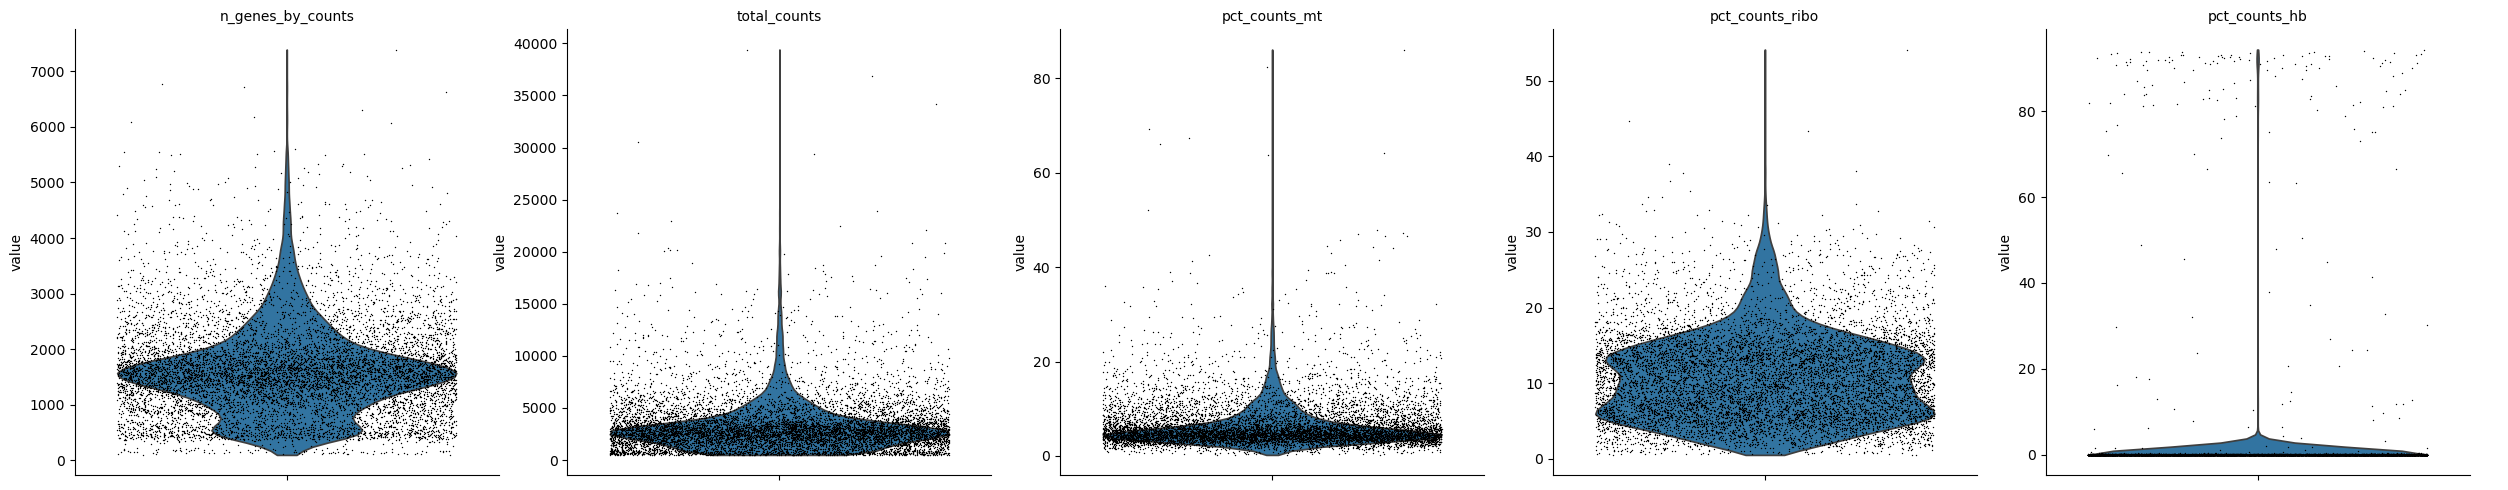

In [56]:
sc.pl.violin(
    sample1,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)

sc.pl.violin(
    sample2,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt", "pct_counts_ribo", "pct_counts_hb"],
    jitter=0.4,
    multi_panel=True,
)

# Plot metrics jointly for each sample

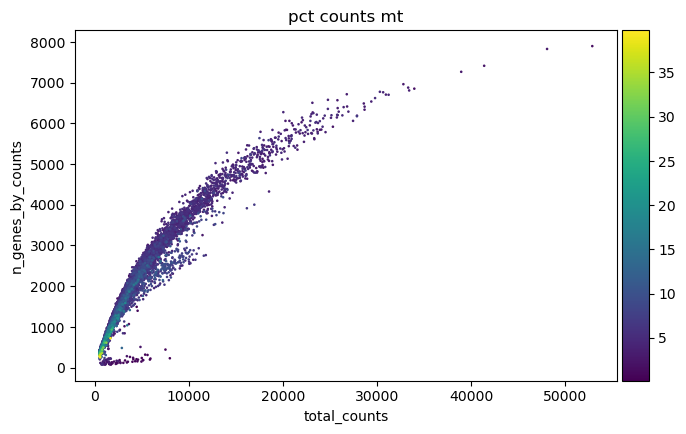

In [57]:
sc.pl.scatter(sample1, "total_counts", "n_genes_by_counts", color="pct_counts_mt")


# Filter your datasets based on the above thresholds and use the built-in scrublet method

In [58]:
sc.pp.filter_cells(sample1, min_genes=100)
sc.pp.filter_genes(sample1, min_cells=3)
#sc.pp.scrublet(sample1)

sc.pp.filter_cells(sample2, min_genes=100)
sc.pp.filter_genes(sample2, min_cells=3)
#sc.pp.scrublet(sample2)

# How many genes and cells were present before and after filtering?

In [59]:
sample2.var

,gene_ids,feature_types,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_cells
Xkr4,ENSMUSG00000051951,Gene Expression,False,False,False,2130,0.461704,0.379603,77.054831,4286.0,8.363342,2130
Gm1992,ENSMUSG00000089699,Gene Expression,False,False,False,176,0.019821,0.019627,98.104061,184.0,5.220356,176
Gm19938,ENSMUSG00000102331,Gene Expression,False,False,False,489,0.060110,0.058373,94.732306,558.0,6.326149,489
Rp1,ENSMUSG00000025900,Gene Expression,False,False,False,29,0.003770,0.003763,99.687601,35.0,3.583519,29
Sox17,ENSMUSG00000025902,Gene Expression,False,False,False,158,0.039750,0.038980,98.297964,369.0,5.913503,158
...,...,...,...,...,...,...,...,...,...,...,...,...
mt-Nd6,ENSMUSG00000064368,Gene Expression,True,False,False,321,0.035980,0.035348,96.542066,334.0,5.814131,321
mt-Cytb,ENSMUSG00000064370,Gene Expression,True,False,False,9248,22.598944,3.161202,0.377033,209786.0,12.253848,9247
ENSMUSG00000079808,ENSMUSG00000079808,Gene Expression,False,False,False,7,0.000754,0.000754,99.924593,7.0,2.079442,7
ENSMUSG00000095742,ENSMUSG00000095742,Gene Expression,False,False,False,9,0.000970,0.000969,99.903049,9.0,2.302585,9


| # of Cells | Sample 1 | Sample 2 |
| ---------- | -------- | -------- |
| Before     |          |          |
| After      |          |          |         


# Combine both samples together using Anndata concat

In [60]:
adata = ad.concat([sample1, sample2], join='outer', label="replicate", keys=["rep1", "rep2"])
adata_celltypist = adata.copy()

In [61]:
adata

AnnData object with n_obs × n_vars = 17883 × 22837
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'replicate'

# Copy counts, normalize counts, and Log(x+1) transform

In [62]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# Determine highly variable genes

In [63]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="replicate")


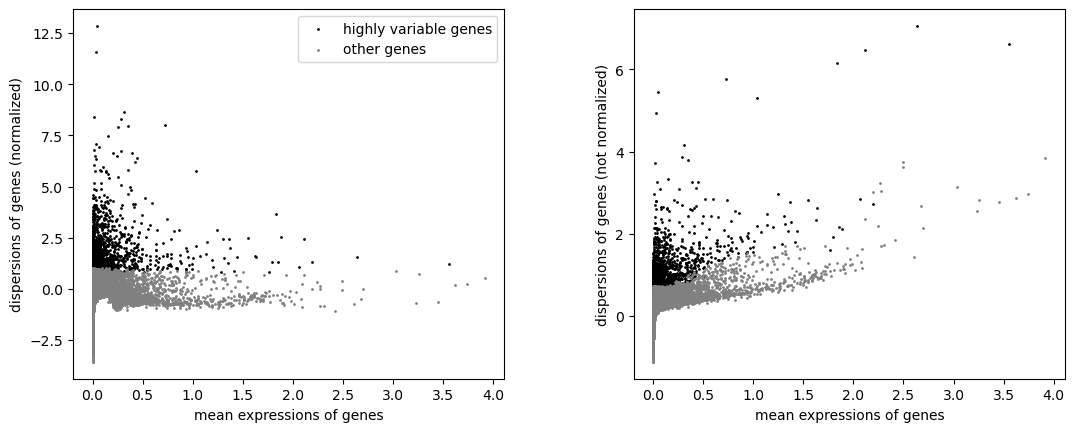

In [64]:
sc.pl.highly_variable_genes(adata)

# Inspect the highly variable genes

In [65]:
adata.var

,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection
0610005C13Rik,False,0.001207,0.002858,-7.768321e-01,0,False
0610006L08Rik,False,0.000165,-0.079359,-4.241872e-01,0,False
0610009B22Rik,False,0.155847,0.342345,1.484185e-02,0,False
0610009E02Rik,False,0.010161,0.408296,2.596138e-01,0,False
0610009L18Rik,False,0.071232,0.348364,5.034095e-02,0,False
...,...,...,...,...,...,...
mt-Nd3,False,0.763551,0.955092,1.855362e-01,0,False
mt-Nd4,False,2.699090,2.133701,-1.110223e-16,0,False
mt-Nd4l,False,0.312788,0.630224,2.905129e-01,0,False
mt-Nd5,False,0.630251,0.789056,-1.076497e-01,0,False


In [66]:
sc.tl.pca(adata)

# Perform PCA and examine PCA - Variance Ratio

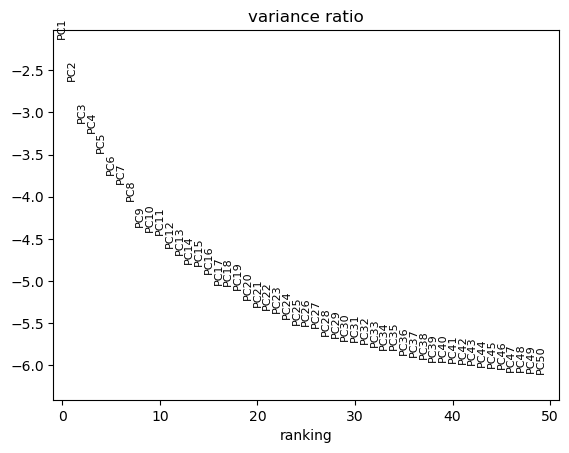

In [67]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

# Compute the nearest neighbors graph

In [68]:
sc.pp.neighbors(adata)

# Run UMAP and be sure to set a random_state

In [69]:
sc.tl.umap(adata, random_state=42)

# Perform Leiden clustering

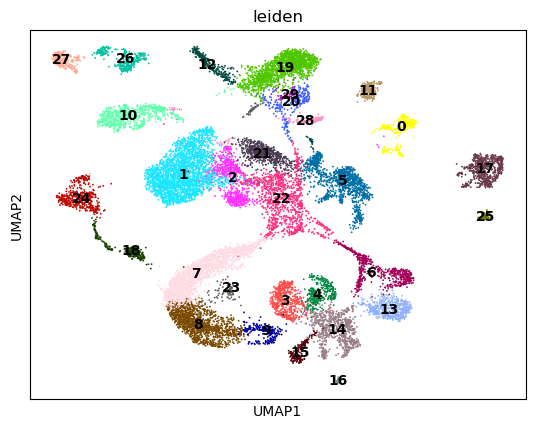

In [70]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
sc.pl.umap(adata, color=["leiden"], legend_loc='on data')

# Overlay Doublet scores onto UMAP (can skip this)

In [71]:
#sc.pl.umap(
#    adata,
#    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
#    wspace=0.5,
#    ncols=1,
#    size=3,
#)

# Overlay QC metrics onto UMAP

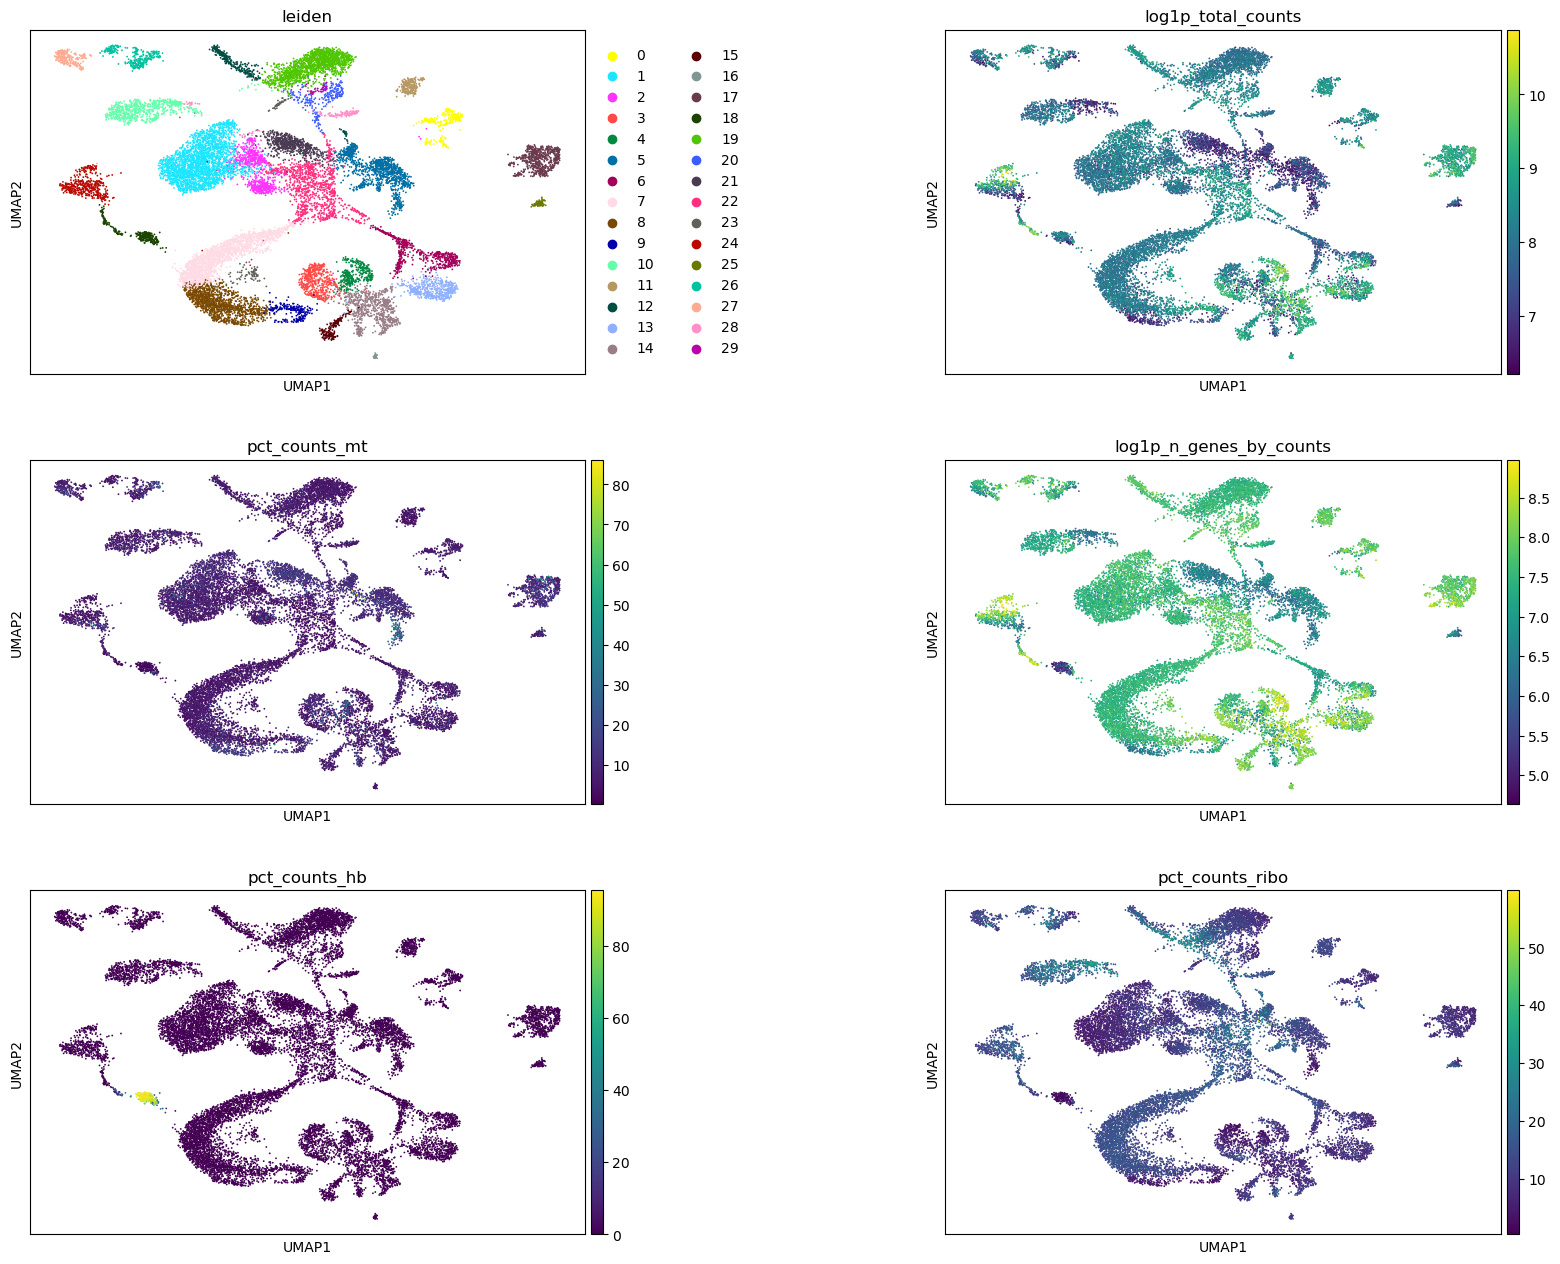

In [72]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts", "pct_counts_hb", "pct_counts_ribo"],
    wspace=0.5,
    ncols=2,
)

# Overlay replicate status onto UMAP

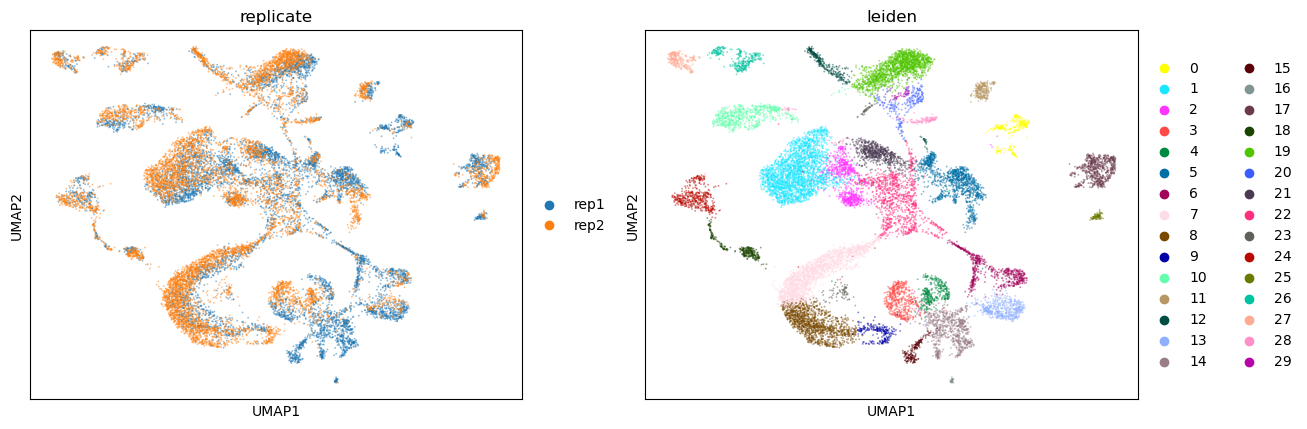

In [73]:
sc.pl.umap(adata,color=["replicate", "leiden"], alpha=0.5)

# Experiment with different resolution values for clustering

In [74]:
sc.tl.leiden(adata, key_added="leiden_res_0.5", resolution=0.5, flavor="igraph")

In [75]:
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,...,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_genes,replicate,leiden,leiden_res_0.5
AAACCTGAGATGCCAG-1,2409,7.787382,4126.0,8.325306,19.946680,25.666505,33.858459,50.096946,346.0,5.849325,...,255.0,5.545177,6.180320,0.0,0.000000,0.000000,2409,rep1,0,0
AAACCTGAGGCGCTCT-1,2273,7.729296,5077.0,8.532673,23.616309,32.263148,43.116013,59.661217,320.0,5.771441,...,660.0,6.493754,12.999803,1.0,0.693147,0.019697,2273,rep1,1,1
AAACCTGCAACACCTA-1,1929,7.565275,3646.0,8.201660,25.150850,32.364235,41.689523,59.544707,214.0,5.370638,...,293.0,5.683580,8.036204,2.0,1.098612,0.054855,1929,rep1,1,1
AAACCTGCATGCCTAA-1,3830,8.250881,10013.0,9.211740,17.367422,25.137321,35.513832,51.612903,369.0,5.913503,...,957.0,6.864848,9.557575,0.0,0.000000,0.000000,3830,rep1,3,2
AAACCTGGTCGAACAG-1,1125,7.026427,1750.0,7.467942,26.457143,34.457143,45.885714,64.285714,118.0,4.779123,...,105.0,4.663439,6.000000,0.0,0.000000,0.000000,1125,rep1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCACATACG-1,1304,7.173958,2179.0,7.687080,22.625057,32.400184,43.965122,63.102341,87.0,4.477337,...,282.0,5.645447,12.941716,0.0,0.000000,0.000000,1304,rep2,8,12
TTTGTCATCCCTTGCA-1,1160,7.057037,1906.0,7.553287,27.282267,35.781742,46.747114,65.372508,157.0,5.062595,...,198.0,5.293305,10.388247,0.0,0.000000,0.000000,1160,rep2,24,17
TTTGTCATCCGTAGTA-1,1607,7.382746,2663.0,7.887584,20.090124,28.051070,38.715734,58.430342,154.0,5.043425,...,254.0,5.541264,9.538115,2.0,1.098612,0.075103,1607,rep2,19,14
TTTGTCATCTAGAGTC-1,2192,7.693026,4351.0,8.378391,26.062974,33.049874,41.990347,58.009653,343.0,5.840641,...,239.0,5.480639,5.492990,1.0,0.693147,0.022983,2192,rep2,1,1


In [76]:
for res in [0.5, 1, 2.0]:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

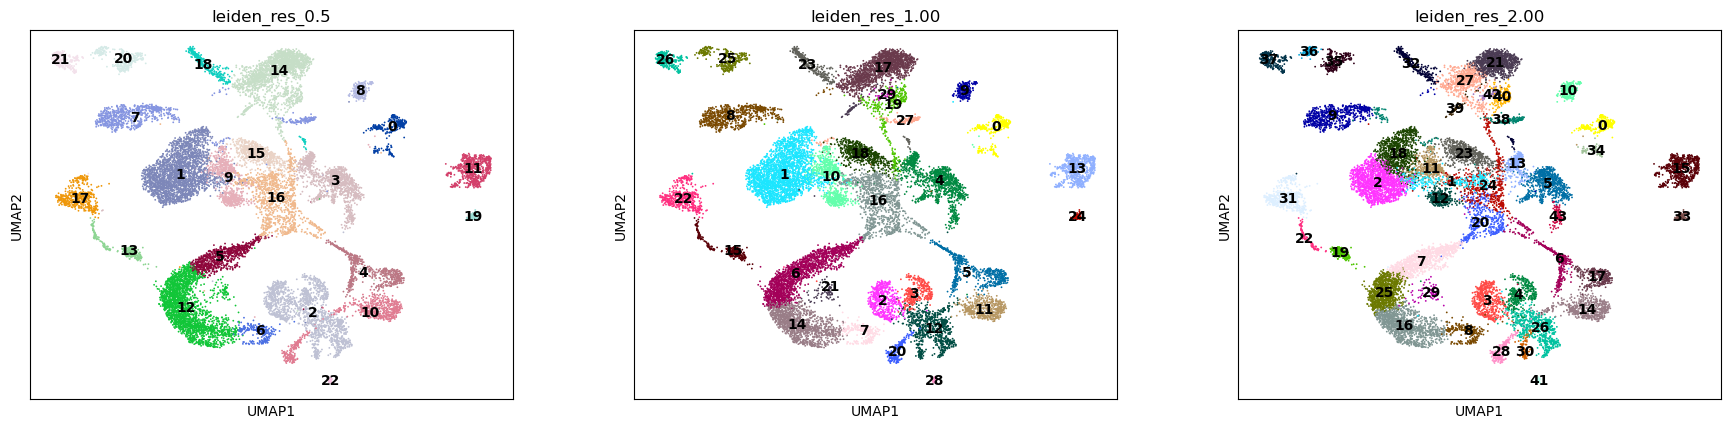

In [77]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.5", "leiden_res_1.00", "leiden_res_2.00"],
    legend_loc="on data",
)

In [ ]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.5", "leiden_res_1.00", "leiden_res_2.00"],
    legend_loc="on data",
)

# Determine differentially expressed marker genes for each cluster

In [78]:
sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.5", method="wilcoxon")

/projectnb/bubhub/users/jorofino/.conda/envs/scanpy_scrnaseq/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/projectnb/bubhub/users/jorofino/.conda/envs/scanpy_scrnaseq/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/projectnb/bubhub/users/jorofino/.conda/envs/scanpy_scrnase

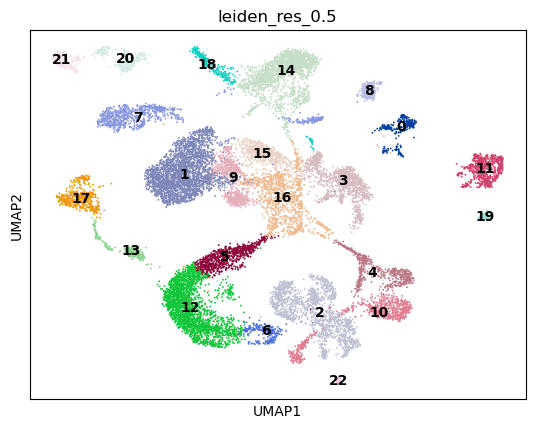

In [79]:
sc.pl.umap(adata, color="leiden_res_0.5",legend_loc="on data")

# Inspect some clustering results

In [120]:
sc.get.rank_genes_groups_df(adata, group="3").head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,mt-Nd1,35.347054,1.068977,1.112692e-273,6.352635e-270
1,mt-Atp6,32.287991,0.826863,1.031272e-228,2.943894e-225
2,mt-Co3,31.140617,0.816750,6.795584e-213,1.410825e-209
3,mt-Cytb,29.808889,0.811958,2.996388e-195,4.887750e-192
4,mt-Nd4,28.049389,0.815667,4.063573e-173,4.639991e-170
5,Tuba1a,27.841368,1.300382,1.370225e-170,1.303826e-167
6,Selenow,27.412523,1.081040,1.944878e-165,1.776607e-162
7,Tmsb10,25.596148,1.401016,1.683883e-144,1.165298e-141
8,Stmn3,24.339586,1.728307,7.473294e-131,4.162625e-128
9,Calm2,23.235270,1.168850,2.004590e-119,9.155764e-117


In [121]:
sc.get.rank_genes_groups_df(adata, group="3").head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,mt-Nd1,35.347054,1.068977,1.112692e-273,6.352635e-270
1,mt-Atp6,32.287991,0.826863,1.031272e-228,2.943894e-225
2,mt-Co3,31.140617,0.816750,6.795584e-213,1.410825e-209
3,mt-Cytb,29.808889,0.811958,2.996388e-195,4.887750e-192
4,mt-Nd4,28.049389,0.815667,4.063573e-173,4.639991e-170
5,Tuba1a,27.841368,1.300382,1.370225e-170,1.303826e-167
6,Selenow,27.412523,1.081040,1.944878e-165,1.776607e-162
7,Tmsb10,25.596148,1.401016,1.683883e-144,1.165298e-141
8,Stmn3,24.339586,1.728307,7.473294e-131,4.162625e-128
9,Calm2,23.235270,1.168850,2.004590e-119,9.155764e-117


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

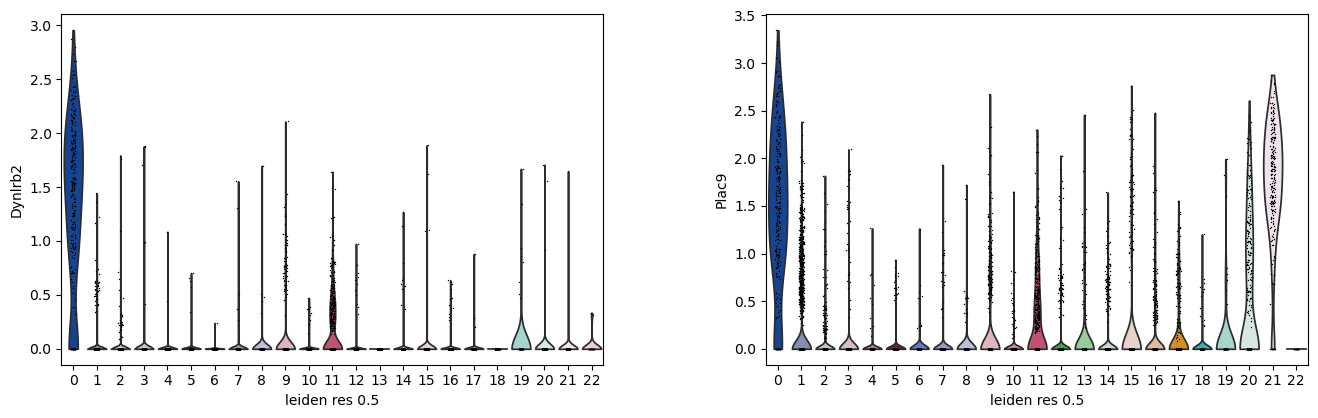

In [81]:
sc.pl.violin(adata, ["Dynlrb2", "Plac9"], groupby="leiden_res_0.5")

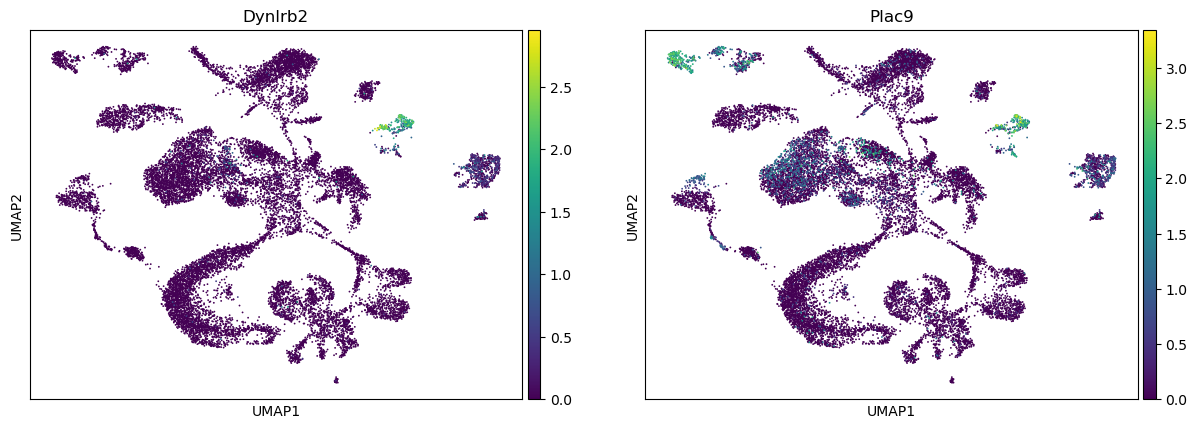

In [82]:
sc.pl.umap(adata, color=["Dynlrb2", "Plac9"])

# Applying automatic annotations

In [ ]:
import celltypist
from celltypist import models

models.models_description()

👉 Detailed model information can be found at `https://www.celltypist.org/models`


,model,description
0,Immune_All_Low.pkl,immune sub-populations combined from 20 tissue...
1,Immune_All_High.pkl,immune populations combined from 20 tissues of...
2,Adult_COVID19_PBMC.pkl,peripheral blood mononuclear cell types from C...
3,Adult_CynomolgusMacaque_Hippocampus.pkl,cell types from the hippocampus of adult cynom...
4,Adult_Human_MTG.pkl,cell types and subtypes (10x-based) from the a...
5,Adult_Human_PancreaticIslet.pkl,cell types from pancreatic islets of healthy a...
6,Adult_Human_PrefrontalCortex.pkl,cell types and subtypes from the adult human d...
7,Adult_Human_Skin.pkl,cell types from human healthy adult skin
8,Adult_Human_Vascular.pkl,vascular populations combined from multiple ad...
9,Adult_Mouse_Gut.pkl,cell types in the adult mouse gut combined fro...


In [ ]:
adata_celltypist.layers["counts"] = adata_celltypist.X.copy()
sc.pp.normalize_total(adata_celltypist, target_sum=10000)
sc.pp.log1p(adata_celltypist)
adata_celltypist.obs_names_make_unique()
adata_celltypist.var_names_make_unique()
predictions = celltypist.annotate(adata_celltypist, model = 'Mouse_Isocortex_Hippocampus.pkl', majority_voting = True)
adata.obs = adata.obs.join(predictions.predicted_labels)

🔬 Input data has 17883 cells and 22837 genes
🔗 Matching reference genes in the model
🧬 3264 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [86]:
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
AAACCTGAGATGCCAG-1,Astro,0,Astro
AAACCTGAGGCGCTCT-1,Astro,1,Astro
AAACCTGCAACACCTA-1,Astro,2,Astro
AAACCTGCATGCCTAA-1,CA1-ProS,5,CA1-ProS
AAACCTGGTCGAACAG-1,Astro,6,Astro
...,...,...,...
TTTGTCATCACATACG-1,DG,53,DG
TTTGTCATCCCTTGCA-1,Endo,89,Endo
TTTGTCATCCGTAGTA-1,Oligo,57,Oligo
TTTGTCATCTAGAGTC-1,Astro,125,Astro


In [98]:
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,...,n_genes,replicate,leiden,leiden_res_0.5,leiden_res_0.50,leiden_res_1.00,leiden_res_2.00,predicted_labels,over_clustering,majority_voting
AAACCTGAGATGCCAG-1,2409,7.787382,4126.0,8.325306,19.946680,25.666505,33.858459,50.096946,346.0,5.849325,...,2409,rep1,0,0,0,0,0,Astro,0,Astro
AAACCTGAGGCGCTCT-1,2273,7.729296,5077.0,8.532673,23.616309,32.263148,43.116013,59.661217,320.0,5.771441,...,2273,rep1,1,1,1,1,1,Astro,1,Astro
AAACCTGCAACACCTA-1,1929,7.565275,3646.0,8.201660,25.150850,32.364235,41.689523,59.544707,214.0,5.370638,...,1929,rep1,1,1,1,1,2,Astro,2,Astro
AAACCTGCATGCCTAA-1,3830,8.250881,10013.0,9.211740,17.367422,25.137321,35.513832,51.612903,369.0,5.913503,...,3830,rep1,3,2,2,2,3,CA1-ProS,5,CA1-ProS
AAACCTGGTCGAACAG-1,1125,7.026427,1750.0,7.467942,26.457143,34.457143,45.885714,64.285714,118.0,4.779123,...,1125,rep1,1,1,1,1,2,Astro,6,Astro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCACATACG-1,1304,7.173958,2179.0,7.687080,22.625057,32.400184,43.965122,63.102341,87.0,4.477337,...,1304,rep2,8,12,12,14,16,DG,53,DG
TTTGTCATCCCTTGCA-1,1160,7.057037,1906.0,7.553287,27.282267,35.781742,46.747114,65.372508,157.0,5.062595,...,1160,rep2,24,17,17,22,31,Endo,89,Endo
TTTGTCATCCGTAGTA-1,1607,7.382746,2663.0,7.887584,20.090124,28.051070,38.715734,58.430342,154.0,5.043425,...,1607,rep2,19,14,14,17,21,Oligo,57,Oligo
TTTGTCATCTAGAGTC-1,2192,7.693026,4351.0,8.378391,26.062974,33.049874,41.990347,58.009653,343.0,5.840641,...,2192,rep2,1,1,1,1,2,Astro,125,Astro


In [99]:
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,...,n_genes,replicate,leiden,leiden_res_0.5,leiden_res_0.50,leiden_res_1.00,leiden_res_2.00,predicted_labels,over_clustering,majority_voting
AAACCTGAGATGCCAG-1,2409,7.787382,4126.0,8.325306,19.946680,25.666505,33.858459,50.096946,346.0,5.849325,...,2409,rep1,0,0,0,0,0,Astro,0,Astro
AAACCTGAGGCGCTCT-1,2273,7.729296,5077.0,8.532673,23.616309,32.263148,43.116013,59.661217,320.0,5.771441,...,2273,rep1,1,1,1,1,1,Astro,1,Astro
AAACCTGCAACACCTA-1,1929,7.565275,3646.0,8.201660,25.150850,32.364235,41.689523,59.544707,214.0,5.370638,...,1929,rep1,1,1,1,1,2,Astro,2,Astro
AAACCTGCATGCCTAA-1,3830,8.250881,10013.0,9.211740,17.367422,25.137321,35.513832,51.612903,369.0,5.913503,...,3830,rep1,3,2,2,2,3,CA1-ProS,5,CA1-ProS
AAACCTGGTCGAACAG-1,1125,7.026427,1750.0,7.467942,26.457143,34.457143,45.885714,64.285714,118.0,4.779123,...,1125,rep1,1,1,1,1,2,Astro,6,Astro
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCACATACG-1,1304,7.173958,2179.0,7.687080,22.625057,32.400184,43.965122,63.102341,87.0,4.477337,...,1304,rep2,8,12,12,14,16,DG,53,DG
TTTGTCATCCCTTGCA-1,1160,7.057037,1906.0,7.553287,27.282267,35.781742,46.747114,65.372508,157.0,5.062595,...,1160,rep2,24,17,17,22,31,Endo,89,Endo
TTTGTCATCCGTAGTA-1,1607,7.382746,2663.0,7.887584,20.090124,28.051070,38.715734,58.430342,154.0,5.043425,...,1607,rep2,19,14,14,17,21,Oligo,57,Oligo
TTTGTCATCTAGAGTC-1,2192,7.693026,4351.0,8.378391,26.062974,33.049874,41.990347,58.009653,343.0,5.840641,...,2192,rep2,1,1,1,1,2,Astro,125,Astro


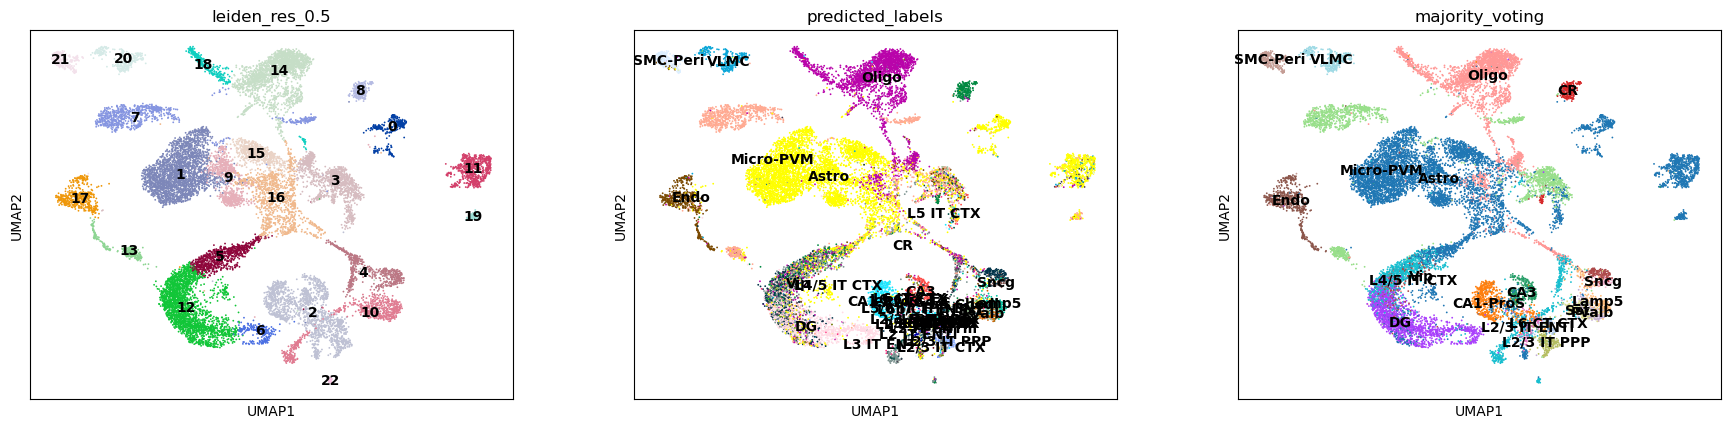

In [89]:
sc.pl.umap(adata, color = ['leiden_res_0.5', 'predicted_labels', 'majority_voting'], legend_loc = 'on data')

In [119]:
sc.get.rank_genes_groups_df(adata, group="14").head(20)

,names,scores,logfoldchanges,pvals,pvals_adj
0,Lhfpl3,70.126633,6.621229,0.0,0.0
1,Olig1,61.678127,4.098558,0.0,0.0
2,Pcdh15,61.368702,3.672281,0.0,0.0
3,Dscam,59.758762,4.088030,0.0,0.0
4,Pdgfra,58.881615,5.775995,0.0,0.0
5,Anks1b,58.234180,2.985473,0.0,0.0
6,Lrrc4c,58.226627,3.176041,0.0,0.0
7,Brinp3,56.592655,4.498023,0.0,0.0
8,Kcnd2,56.445427,3.034955,0.0,0.0
9,Rpl13,56.133217,1.566238,0.0,0.0


In [ ]:
cell_types = {'1': "micro-pvm", '2': 'CA3'}

In [110]:
adata.obs['manual_annotations'] = adata.obs['leiden_res_0.50'].map(cell_types)

In [118]:
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,...,replicate,leiden,leiden_res_0.5,leiden_res_0.50,leiden_res_1.00,leiden_res_2.00,predicted_labels,over_clustering,majority_voting,manual_annotations
AAACCTGAGATGCCAG-1,2409,7.787382,4126.0,8.325306,19.946680,25.666505,33.858459,50.096946,346.0,5.849325,...,rep1,0,0,0,0,0,Astro,0,Astro,NaN
AAACCTGAGGCGCTCT-1,2273,7.729296,5077.0,8.532673,23.616309,32.263148,43.116013,59.661217,320.0,5.771441,...,rep1,1,1,1,1,1,Astro,1,Astro,micro-pvm
AAACCTGCAACACCTA-1,1929,7.565275,3646.0,8.201660,25.150850,32.364235,41.689523,59.544707,214.0,5.370638,...,rep1,1,1,1,1,2,Astro,2,Astro,micro-pvm
AAACCTGCATGCCTAA-1,3830,8.250881,10013.0,9.211740,17.367422,25.137321,35.513832,51.612903,369.0,5.913503,...,rep1,3,2,2,2,3,CA1-ProS,5,CA1-ProS,NaN
AAACCTGGTCGAACAG-1,1125,7.026427,1750.0,7.467942,26.457143,34.457143,45.885714,64.285714,118.0,4.779123,...,rep1,1,1,1,1,2,Astro,6,Astro,micro-pvm
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCACATACG-1,1304,7.173958,2179.0,7.687080,22.625057,32.400184,43.965122,63.102341,87.0,4.477337,...,rep2,8,12,12,14,16,DG,53,DG,NaN
TTTGTCATCCCTTGCA-1,1160,7.057037,1906.0,7.553287,27.282267,35.781742,46.747114,65.372508,157.0,5.062595,...,rep2,24,17,17,22,31,Endo,89,Endo,NaN
TTTGTCATCCGTAGTA-1,1607,7.382746,2663.0,7.887584,20.090124,28.051070,38.715734,58.430342,154.0,5.043425,...,rep2,19,14,14,17,21,Oligo,57,Oligo,NaN
TTTGTCATCTAGAGTC-1,2192,7.693026,4351.0,8.378391,26.062974,33.049874,41.990347,58.009653,343.0,5.840641,...,rep2,1,1,1,1,2,Astro,125,Astro,micro-pvm
